In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [3]:
df.head()
df.shape
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


# Data Cleaning

In [4]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(2640, 12)

# Exploratory Data Analysis

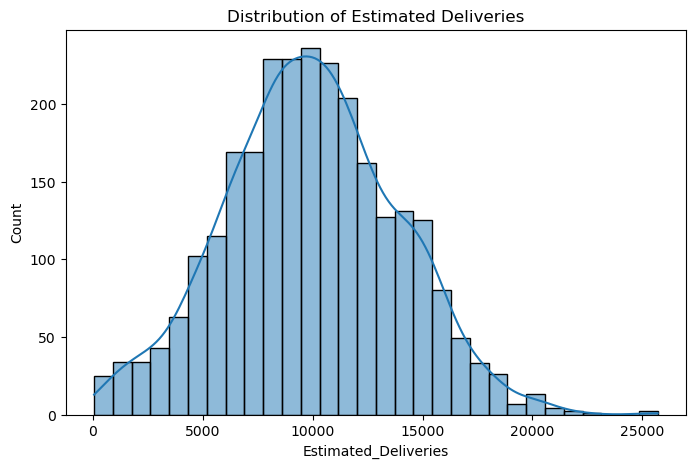

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.show()

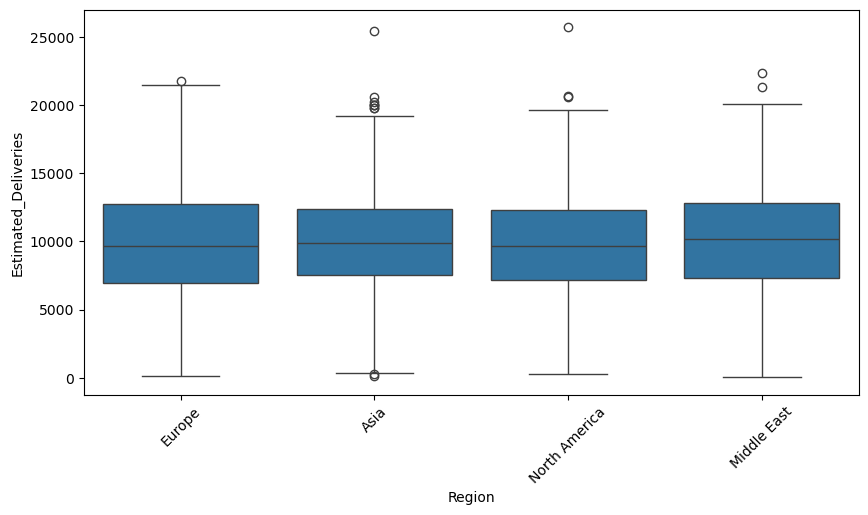

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.show()

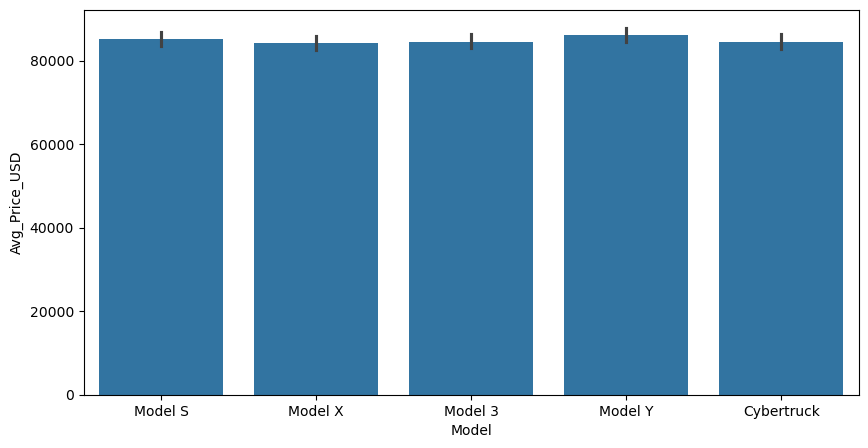

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Avg_Price_USD"
)

plt.show()

# Feature Engineering

In [10]:
df["Quarter"] = ((df["Month"] - 1) // 3) + 1

In [11]:
df["Production_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [12]:
df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

In [13]:
df["CO2_per_Delivery"] = (
    df["CO2_Saved_tons"] /
    df["Estimated_Deliveries"]
)

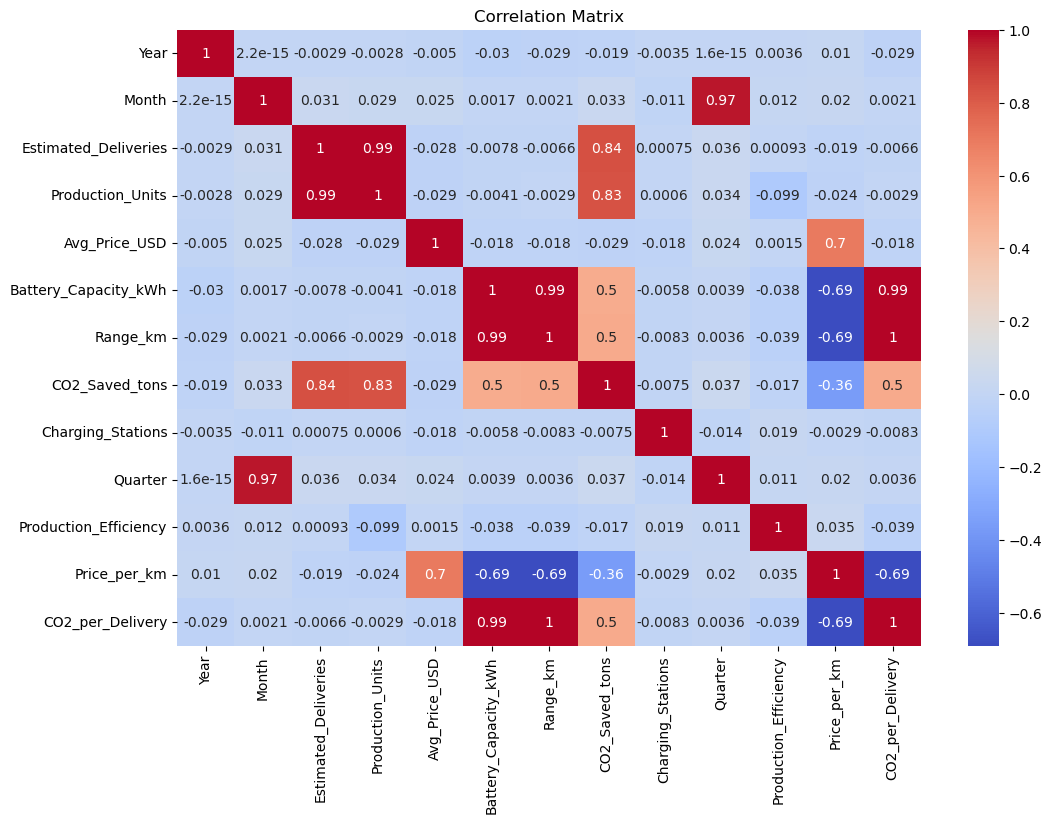

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# One-hot-Encoding

In [15]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False
)

In [16]:
encoded = ohe.fit_transform(
    df[["Region", "Source_Type", "Model"]]
)

In [17]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(
        ["Region", "Source_Type", "Model"]
    ),
    index=df.index)

In [18]:
df = df.drop(columns=["Region", "Source_Type", "Model"])

In [19]:
df = pd.concat([df, encoded_df],axis=1)

# Train-Test-Split

In [20]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

In [22]:
X_test.head()

,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Quarter,Production_Efficiency,...,CO2_per_Delivery,Region_Europe,Region_Middle East,Region_North America,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
2005,2016,10,7968,77791.05,60,332,348.15,10404,4,0.877385,...,0.049800,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32,2020,9,10117,100029.16,100,596,833.74,13947,3,0.921815,...,0.089400,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
962,2024,12,9355,68450.11,82,459,623.85,12180,4,0.968573,...,0.068850,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1461,2025,4,10171,86288.53,100,553,742.49,4323,2,0.880051,...,0.082951,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
478,2024,5,9536,109940.95,75,430,561.60,5600,2,0.913066,...,0.064500,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [23]:
X_train.head()

,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Quarter,Production_Efficiency,...,CO2_per_Delivery,Region_Europe,Region_Middle East,Region_North America,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
2387,2022,2,11285,50815.14,60,346,548.63,10938,1,0.936730,...,0.05190,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1187,2019,1,6229,91420.19,75,419,351.33,11000,1,0.897415,...,0.06285,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2396,2016,1,10885,82383.61,82,486,763.99,11726,1,0.962793,...,0.07290,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
440,2020,1,13257,85609.42,82,460,846.42,11937,1,0.925322,...,0.06900,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
508,2024,4,17286,58222.35,60,350,804.25,7906,2,0.886208,...,0.05250,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [24]:
df.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Quarter,...,CO2_per_Delivery,Region_Europe,Region_Middle East,Region_North America,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,2,...,0.105600,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,1,...,0.065699,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,1,...,0.072000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,1,...,0.106799,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,4,...,0.099150,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [27]:
r2 = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression:")
print("R² Score :", (r2))
print("RMSE     :", (rmse))

Linear Regression:
R² Score : 0.9984122097020592
RMSE     : 153.844270862438


# Random Forest Regressor

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [29]:
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest:")
print("R² Score :", r2)
print("RMSE     :", rmse)

Random Forest:
R² Score : 0.9991376827119833
RMSE     : 113.37526166653173


# Hyperparamter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [31]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [32]:
print("Best CV R² Score:")
print(round(grid_search.best_score_, 4))

Best CV R² Score:
0.9983


In [33]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [34]:
r2 = r2_score(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
print("Tuned Random Forest Results")
print("R² Score :", r2)
print("RMSE     :",rmse)

Tuned Random Forest Results
R² Score : 0.9991482770956038
RMSE     : 112.67664808249334


# ARIMA

In [35]:
df["Date"] = pd.to_datetime(
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1))

In [36]:
monthly_deliveries = (df.groupby("Date")
      ["Estimated_Deliveries"]
      .sum()
      .sort_index())

In [37]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    monthly_deliveries,
    order=(2,1,2)
)

arima_result = arima_model.fit()

C:\Users\geetb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\geetb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\geetb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [38]:
forecast = arima_result.forecast(
    steps=12
)
print(forecast)

2026-01-01    201434.637522
2026-02-01    200328.856459
2026-03-01    199801.924388
2026-04-01    199648.939935
2026-05-01    199597.002261
2026-06-01    199580.316050
2026-07-01    199574.853365
2026-08-01    199573.076587
2026-09-01    199572.497385
2026-10-01    199572.308719
2026-11-01    199572.247248
2026-12-01    199572.227221
Freq: MS, Name: predicted_mean, dtype: float64


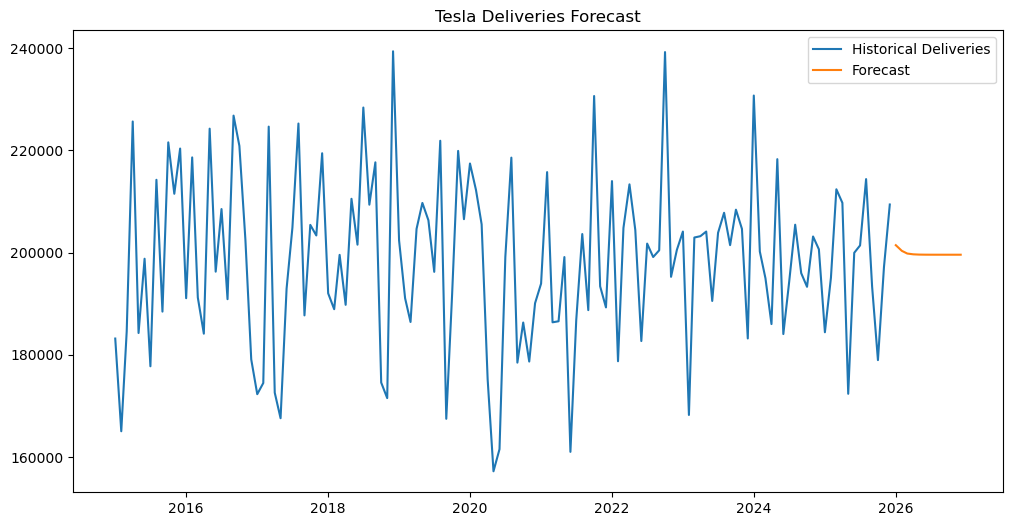

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_deliveries,
    label="Historical Deliveries"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast")
plt.legend()

plt.show()